# Customer Behavior Segmentation - NYC Taxi
**Role:** ML Engineer 1 (Harry Phalosa Telaumbanua)  
**Tujuan:** Mengelompokkan data perjalanan taksi New York menjadi segmen perilaku (persona) yang informatif menggunakan K-Means Clustering untuk mendukung visualisasi pada Dashboard Geospasial.

Pipeline ini menerapkan teknik *Log-Transformation* untuk menangani distribusi data yang miring (*right-skewed*) serta *Standardization* untuk menyamakan skala fitur.

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import os
import warnings

# Konfigurasi Tampilan
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Ingesti Data & Stratified Sampling
Tahap ini memuat data hasil integrasi yang dibersihkan oleh tim Data Engineer. Mengingat volume data yang sangat besar (14,5 Juta baris), diterapkan metode *stratified sampling* berbasis zona penjemputan dengan `seed=42` untuk menjaga konsistensi dan representasi geografis secara akurat.

In [ ]:
print("Memuat data dari Data Engineer...")
file_path = "../data_engineer/data/intermediate/fact_trips_with_weather.parquet"
df = pl.read_parquet(file_path)

print("Memulai Stratified Sampling ...")

# 1. Mengacak seluruh urutan baris data menggunakan seed 42
df_shuffled = df.sample(fraction=1.0, shuffle=True, seed=42)

# 2. Mengambil maksimal 10.000 baris pertama dari setiap zona
df_sampled = df_shuffled.group_by("pickup_zone").head(10000)

# 3. Menghitung jumlah perjalanan untuk menyaring zona yang datanya sedikit
zone_counts = df_sampled.group_by("pickup_zone").agg(pl.count().alias("jumlah_baris"))

# 4. Mempertahankan zona yang datanya minimal 2.000 baris
valid_zones = zone_counts.filter(pl.col("jumlah_baris") >= 2000).select("pickup_zone")

# 5. Menggabungkan data
df_final_sample = df_sampled.join(valid_zones, on="pickup_zone", how="inner")

print(f"Sampling selesai! Sisa baris data yang akan dimasukkan ke model: {df_final_sample.height:,}")

Memuat data dari Data Engineer...
Memulai Stratified Sampling (Original V4 Seed)...
Sampling selesai! Sisa baris data yang akan dimasukkan ke model: 1,021,674


## 2. Feature Engineering & Log-Transformation
Fitur perilaku utama yang digunakan adalah: **Jarak (`trip_distance`), Durasi (`trip_duration_min`), dan Tingkat Tip (`tip_rate_pct`)**.
Untuk mengatasi distribusi data operasional taksi yang miring ke kanan (*right-skewed*), fungsi transformasi logaritma (`np.log1p`) diterapkan pada fitur jarak dan durasi guna membentuk distribusi yang mendekati normal (lonceng).

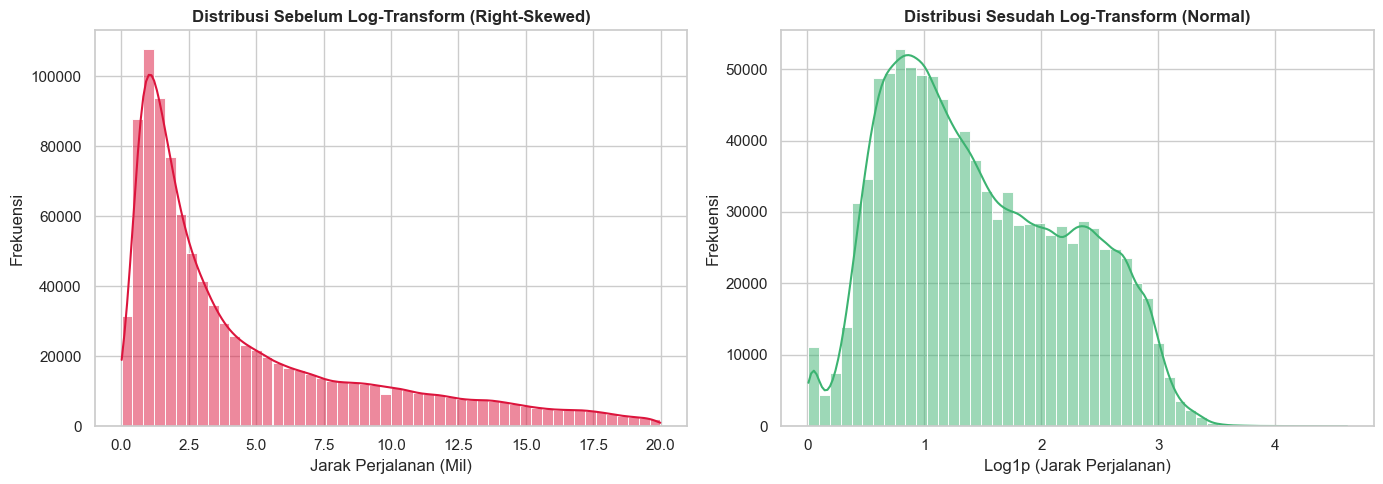

In [3]:
# Ekstraksi sampel fitur jarak untuk analisis distribusi
distance_raw = df_final_sample.select("trip_distance").drop_nulls().to_numpy().flatten()
distance_log = np.log1p(distance_raw)

# Visualisasi efek Log-Transformation
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot sebelum transformasi
sns.histplot(distance_raw[distance_raw < 20], bins=50, kde=True, ax=ax[0], color="crimson")
ax[0].set_title("Distribusi Sebelum Log-Transform (Right-Skewed)", fontweight='bold')
ax[0].set_xlabel("Jarak Perjalanan (Mil)")
ax[0].set_ylabel("Frekuensi")

# Plot setelah transformasi
sns.histplot(distance_log, bins=50, kde=True, ax=ax[1], color="mediumseagreen")
ax[1].set_title("Distribusi Sesudah Log-Transform (Normal)", fontweight='bold')
ax[1].set_xlabel("Log1p (Jarak Perjalanan)")
ax[1].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

In [4]:
# 1. SELEKSI FITUR (Pilar Utama: Jarak, Durasi, Tip)
selected_features = ["trip_distance", "trip_duration_min", "tip_rate_pct"]
df_model = df_final_sample.drop_nulls(subset=selected_features)
X_raw = df_model.select(selected_features).to_numpy()

# 2. LOG TRANSFORMATION (Pada Jarak dan Durasi)
X_log = np.copy(X_raw)
X_log[:, 0] = np.log1p(X_raw[:, 0])
X_log[:, 1] = np.log1p(X_raw[:, 1])

# 3. SCALING (StandardScaler sangat optimal setelah distribusi dinormalkan)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print(f"Data siap dilatih. Bentuk Array: {X_scaled.shape}")

Data siap dilatih. Bentuk Array: (1021674, 3)


## 3. Pelatihan Model & Evaluasi K-Means
Proses klasterisasi dijalankan menggunakan algoritma `MiniBatchKMeans` dengan nilai parameter $K=3$ dan `n_init=10`. Evaluasi performa model diukur secara kuantitatif melalui skor *Silhouette Coefficient* dan *Davies-Bouldin Index*, serta dievaluasi kualitatif dengan visualisasi PCA.

Melatih model K-Means dengan inisialisasi optimal (n_init=10)...

=== HASIL EVALUASI MODEL FINAL ===
1. Silhouette Score     : 0.450 (Mendekati 1 = Baik)
2. Davies-Bouldin Index : 0.713 (Mendekati 0 = Baik)


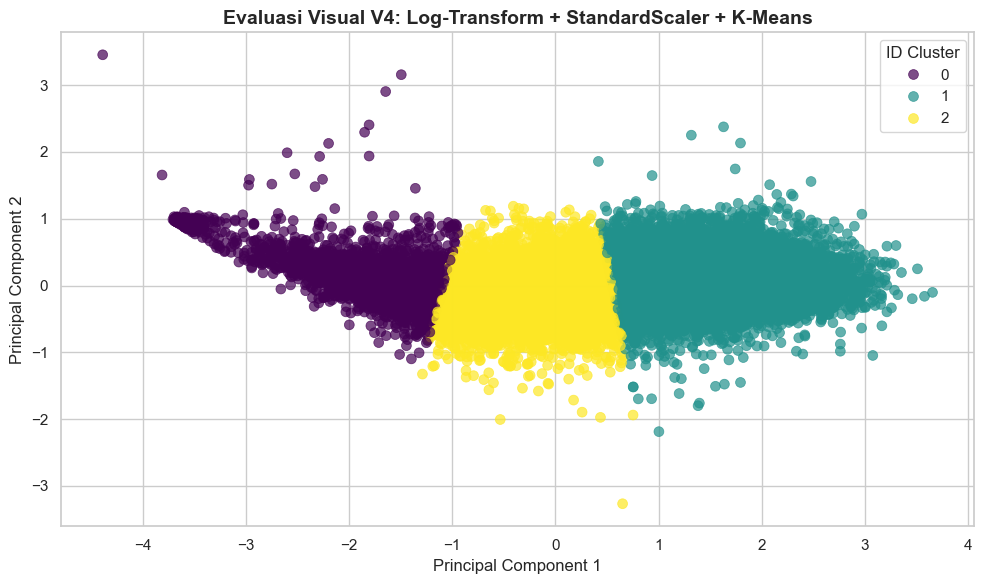

In [5]:
print("Melatih model K-Means dengan inisialisasi optimal (n_init=10)...")
kmeans = MiniBatchKMeans(n_clusters=3, random_state=42, batch_size=3072, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Mengambil 20.000 sampel acak dengan seed 42 untuk perhitungan evaluasi yang konsisten
np.random.seed(42)
eval_indices = np.random.choice(X_scaled.shape[0], size=20000, replace=False)
X_eval = X_scaled[eval_indices]
labels_eval = cluster_labels[eval_indices]

# Kalkulasi skor evaluasi internal
sil_score = silhouette_score(X_eval, labels_eval)
db_score = davies_bouldin_score(X_eval, labels_eval)

print(f"\n=== HASIL EVALUASI MODEL FINAL ===")
print(f"1. Silhouette Score     : {sil_score:.3f} (Mendekati 1 = Baik)")
print(f"2. Davies-Bouldin Index : {db_score:.3f} (Mendekati 0 = Baik)")

# Reduksi dimensi menggunakan PCA untuk analisis visualisasi
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_eval)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=labels_eval, 
    palette='viridis', 
    alpha=0.7, 
    s=50, 
    edgecolor=None
)
plt.title('Evaluasi Visual V4: Log-Transform + StandardScaler + K-Means', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='ID Cluster')
plt.tight_layout()
plt.show()

## 4. Analisis Karakteristik Klaster & Ekspor Data
Bagian ini mengidentifikasi profil rata-rata untuk setiap klaster guna memberikan label persona penumpang. Setelah dilabeli, dataset diekspor ke dalam format `.parquet` sebagai bahan baku bagi Data Analyst untuk membangun *dashboard*.

In [6]:
# Menggabungkan label klaster ke dalam dataframe utama
df_segmented = df_final_sample.with_columns(pl.Series(name="cluster_id", values=cluster_labels))

# Analisis statistik deskriptif rata-rata fitur per klaster
profile = df_segmented.group_by("cluster_id").agg([
    pl.count().alias("jumlah_perjalanan"),
    pl.col("trip_distance").mean().round(2).alias("avg_jarak_mil"),
    pl.col("trip_duration_min").mean().round(2).alias("avg_durasi_menit"),
    pl.col("tip_rate_pct").mean().round(2).alias("avg_tip_persen"),
    pl.col("fare_amount").mean().round(2).alias("avg_tarif_$")
]).sort("cluster_id")

print("Profil Karakteristik Klaster:")
display(profile)

# Pemetaan ID klaster ke representasi label persona bisnis
# Sesuaikan jika posisi klaster 0, 1, 2 bergeser urutannya
cluster_mapping = {
    "0": "Short Daily Commute",   
    "1": "Mid-Range Travel",      
    "2": "Long-Distance / Airport" 
}

df_final_labelled = df_segmented.with_columns(
    pl.col("cluster_id").cast(pl.String).replace(cluster_mapping).alias("customer_segment")
)

# Penyimpanan berkas akhir ke dalam format Parquet
output_file = "../data_engineer/data/intermediate/segmented_trips_final.parquet"
df_final_labelled.write_parquet(output_file)

print(f"\nProses ekspor selesai.")
print(f"Berkas tersimpan di: {output_file} ({os.path.getsize(output_file)/(1024*1024):.2f} MB)")

Profil Karakteristik Klaster:


cluster_id,jumlah_perjalanan,avg_jarak_mil,avg_durasi_menit,avg_tip_persen,avg_tarif_$
i32,u32,f64,f64,f64,f64
0,237031,0.87,5.92,24.66,12.23
1,355261,10.61,52.6,5.66,44.13
2,429382,2.64,18.06,16.06,19.42



Proses ekspor selesai.
Berkas tersimpan di: ../data_engineer/data/intermediate/segmented_trips_final.parquet (40.33 MB)
